In [1]:
import sys
import os
from pathlib import Path
codegen_directory = Path(os.getcwd()) / 'mhe/codegen'
print("working_directory:", codegen_directory)
sys.path.insert(0, str(codegen_directory))
import numpy as np
from commom_utils.ode_system import ODESystem, check_system_ok, MHESyntheticDataGenerator
import numpy as np
import matplotlib.pyplot as plt

from gauss_newton.gauss_newton_math import SystemJacobian
import mhe.mhe_kinematic_model as mhe_kinematic_model
import mhe.mhe_dynamic_model as mhe_dynamic_model
import mhe.mhe_test_model as mhe_test_model
from commom_utils.systems import *
from mhe.mhe_base_model_interface import MheModel
from params import MheParams
from mhe.mhe_utils import MheEstimationData, run_mhe_estimation, plot_mhe_results

working_directory: /home/iachichkanov/autotech/lateral-controler/identification/mhe/codegen


In [2]:
mhe_horizont = 400
ts = 0.02


if(0):   
    use_offset = True   # assume offset is used; adjust later
    measurements_residual_r = np.diag([1, 1])                 # R: 1x1
    state_prior_q0 = np.diag([1, 1])                          # Q0: 1x1
    noise_peanlty_w = np.eye(2) * 1e3                    # Q: 1x1
    fim_scaler = 0.2
    wheel_base = 2.65

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            params_prior_p0=None,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            fim_scaler=fim_scaler,
            wheelbase=None,
            use_offset=None,
            use_only_offset=None
        )

    mhe_params.print()
    generator = mhe_test_model.OscilatorMheCodegenerator(mhe_params, Path(os.getcwd())/'mhe/tmp_generated', 'test_mhe')
    system = MassSpringDamper()
    c0 = np.array([1.0, 10.0]) 
    theta_true = np.array([3, 1.0])
elif(1):
    measurements_residual_r = np.diag([1])                 # R: 1x1
    state_prior_q0 = np.diag([1])                          # Q0: 1x1
    noise_peanlty_w = np.eye(1) * 1e3                    # Q: 1x1
    fim_scaler = 0.2
    wheel_base = 2.65

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            params_prior_p0=None,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            fim_scaler=fim_scaler,
            wheelbase=2.65,
            use_offset=True,
            use_only_offset=False
        )

    mhe_params.print()
    generator = mhe_kinematic_model.KinematicMheCodegenerator(mhe_params, Path(os.getcwd())/'mhe/tmp_generated', 'kinematik_mhe')
    system =  KinematicBycicle(wheelbase = mhe_params.wheelbase)
    c0 = np.array([0]) 
    theta_true = np.array([0.05, np.deg2rad(-0.3)])

check_system_ok(system)
#generator = mhe_kinematic_model.KinematicMheCodegenerator(mhe_params, Path(os.getcwd())/'tmp_codegen', 'kinematik_mhe')
acados_solver_mhe = generator.generate_code()
mhe_model = generator.get_model()


INFO:2026-04-03 11:49:05,617:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-04-03 11:49:05,617 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


dt: 0.02
mhe_horizont: 400
state_prior_q0: [[1]]
params_prior_p0: None
noise_peanlty_w: [[1000.]]
measurements_residual_r: [[1]]
fim_scaler: 0.2
wheelbase: 2.65
use_offset: True
use_only_offset: False
Please export ACADOS_SOURCE_DIR to avoid this warning.
[ 0.         -0.05235988]
[20.          0.05235988]
[1 2]
kinematik_mhe
2 1
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please e

In [ ]:
# Create the generator
data_gen = MHESyntheticDataGenerator(system, sigma=0)

# Parameters
t0 = 0
T_f = mhe_params.dt * mhe_params.mhe_horizont          
N_measurement = mhe_params.mhe_horizont               
overlap_points = int(N_measurement*0.5)
num_windows = 30                                    # number of overlapping windows


# Generate exact windows
t_windows, u_windows, meas_windows, full_windows = data_gen.generate_sliding_windows_exact(
    c0, theta_true, t0, T_f, num_windows, N_measurement, overlap_points=overlap_points
)

# Check the time span of the first window
print(f"Window 0: start={t_windows[0][0]:.6f}, end={t_windows[0][-1]:.6f}, span={t_windows[0][-1]-t_windows[0][0]:.6f}")
# This should equal T_f
def get_window(i):
    return t_windows[i], u_windows[i], meas_windows[i]

Window 0: start=0.000000, end=8.000000, span=8.000000


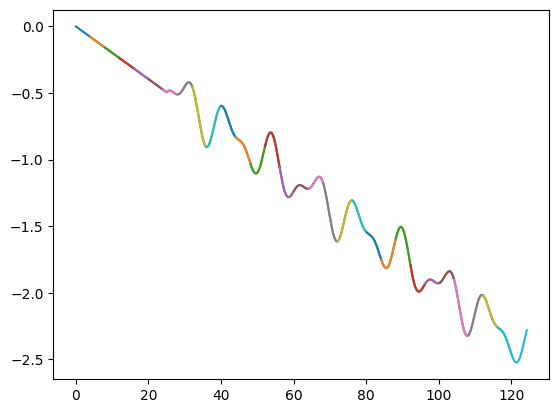

In [ ]:



for i in range(0, num_windows):
    t, simU, simY = get_window(i)
    plt.plot(t, simY)




array([[1]])

In [16]:
initial_theta = theta_true*0.8

results = run_mhe_estimation(
    mhe_model=mhe_model,
    acados_solver_factory= acados_solver_mhe,   # you might pass a pre‑created solver or a factory
    get_window_func=get_window,
    overlap_points=overlap_points,
    initial_theta = initial_theta,
    mhe_params=mhe_params,
    num_windows=num_windows,
    R_inv=mhe_params.measurements_residual_r,
    forgetting_factor = 0.01,
    compute_advanced_fim = True,
    plot=0   # set to True if you want live plots
)

MHE windows: 100%|██████████| 30/30 [00:06<00:00,  4.49window/s]


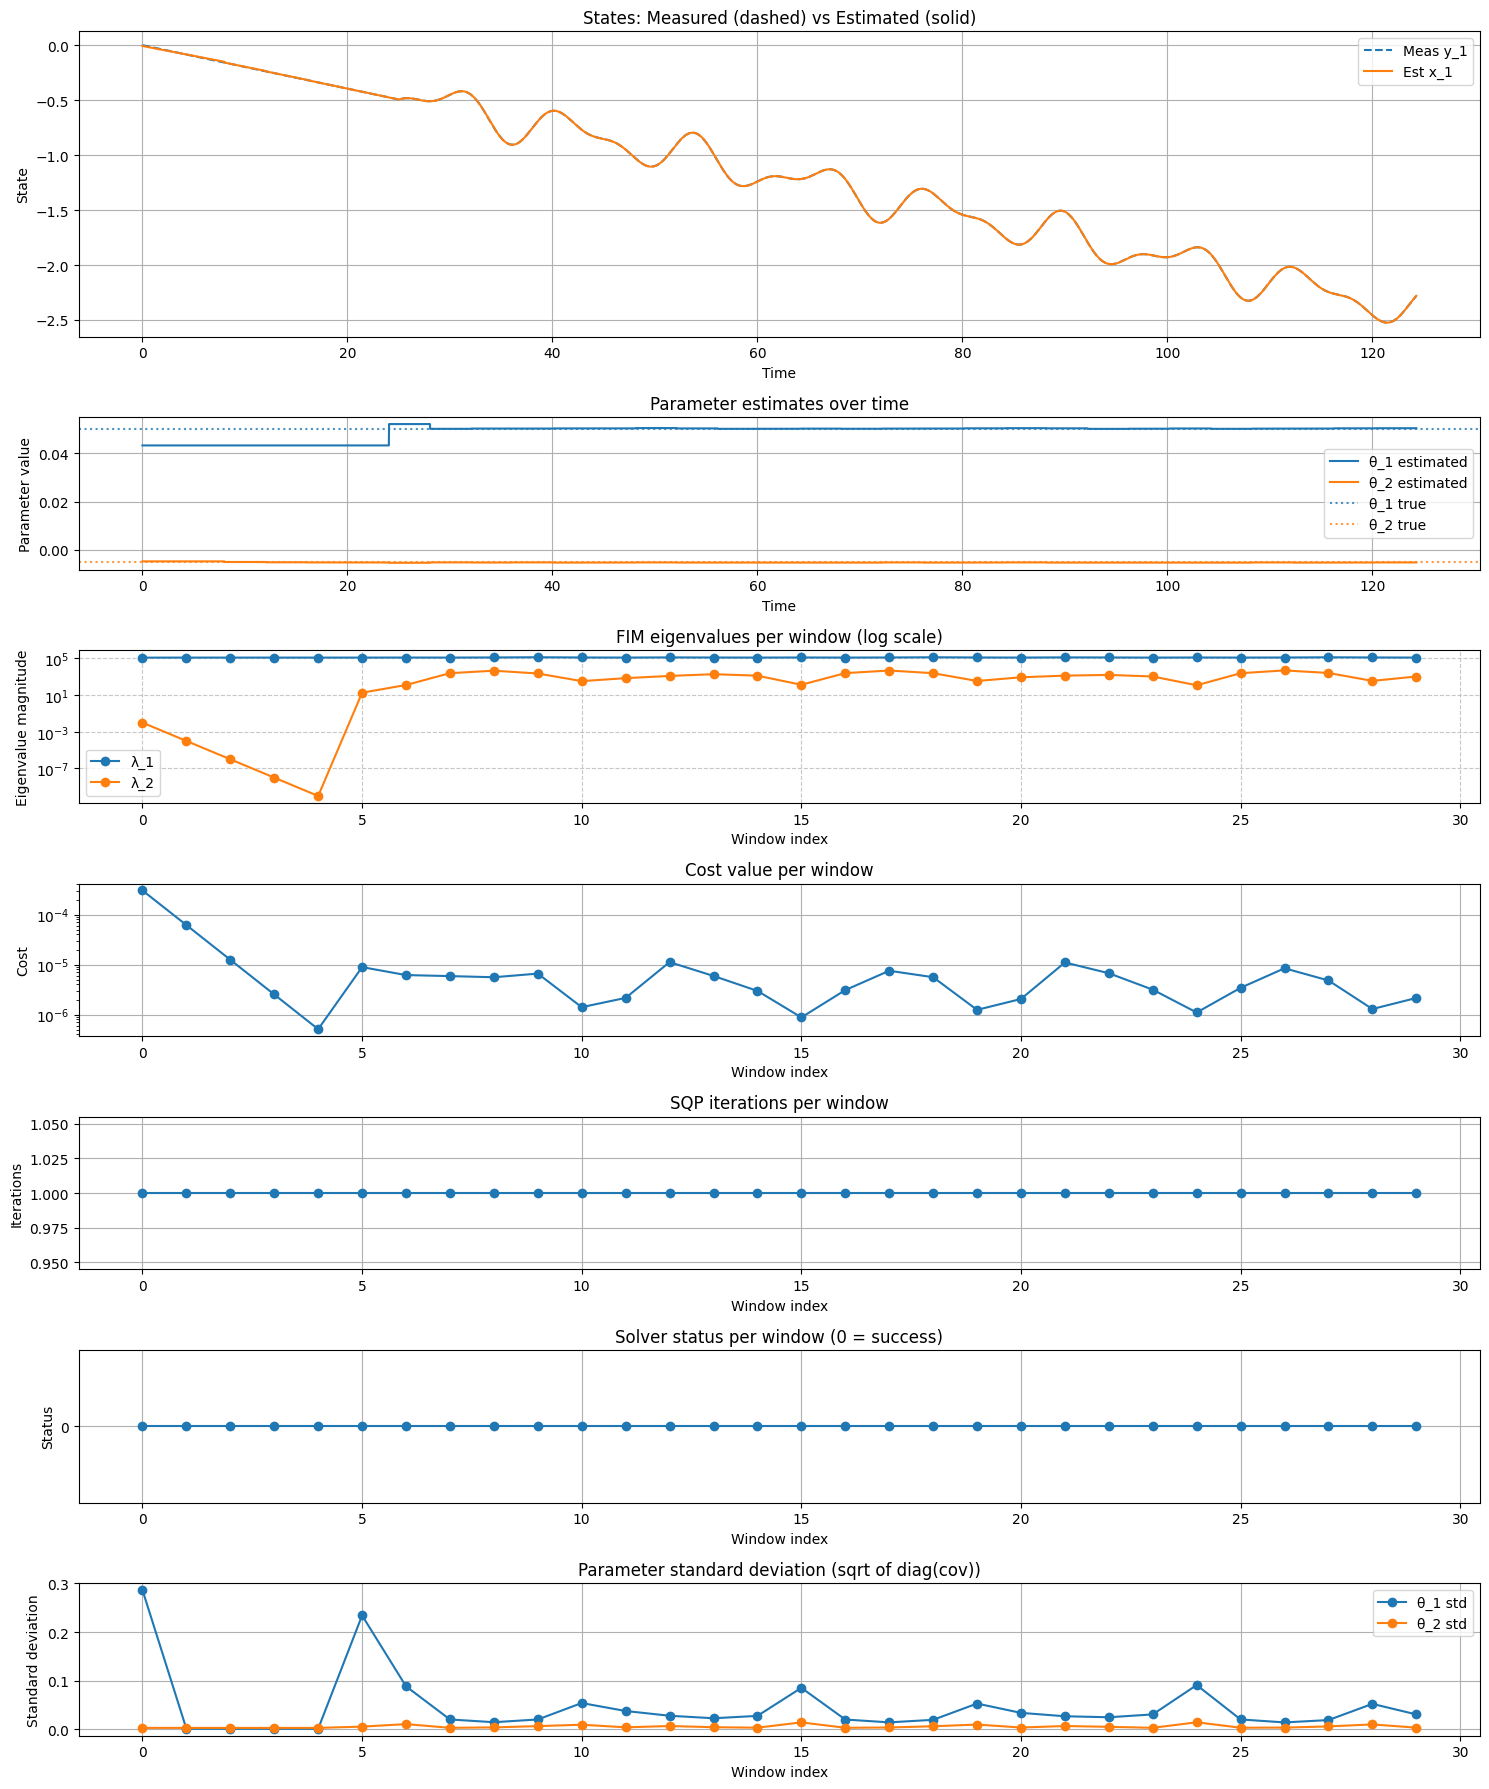

In [17]:
plot_mhe_results(results, overlap=overlap_points,
                 initial_params=None,
                 theta_true=theta_true,   # your true parameter array
                 plot_states=True,
                 plot_params=True,
                 plot_eigvals=True,
                 plot_noise=False,
                 plot_cost=True,
                 plot_iter=True,
                 plot_status=True,
                 figsize=(15, 18))   # slightly larger to accommodate taller first plot

In [12]:
initial_theta = theta_true
t_batch, simU, simY = get_window(1)
unknown_state_length = 0


initial_x0 = np.hstack((simY[0]))
print(initial_x0)
R_inv = np.diag([1])

F = mhe_model.compute_fim( simY.shape[0], mhe_params.dt, simU, initial_x0, initial_theta, R_inv)
F
#set_mhe_solver(mhe_model, acados_solver_mhe, simY, simU, initial_x0, initial_theta, mhe_params.dt, N_measurement, unknown_state_length, R_inv)

[-0.07923258]


array([[     0.        ,      0.        ],
       [     0.        , 121976.92649964]])